In [1]:
print(1)

1


In [2]:
import anndata as ad
import os
import pandas as pd
import s3fs

## Download reported data

In [3]:
fs = s3fs.S3FileSystem(anon=True)

In [4]:
fs.ls('s3://openproblems-data/resources/task_perturbation_prediction/results/run_2024-10-31_06-14-14')

['openproblems-data/resources/task_perturbation_prediction/results/run_2024-10-31_06-14-14/',
 'openproblems-data/resources/task_perturbation_prediction/results/run_2024-10-31_06-14-14/dataset_uns.yaml',
 'openproblems-data/resources/task_perturbation_prediction/results/run_2024-10-31_06-14-14/method_configs.yaml',
 'openproblems-data/resources/task_perturbation_prediction/results/run_2024-10-31_06-14-14/metric_configs.yaml',
 'openproblems-data/resources/task_perturbation_prediction/results/run_2024-10-31_06-14-14/predictions',
 'openproblems-data/resources/task_perturbation_prediction/results/run_2024-10-31_06-14-14/score_uns.yaml',
 'openproblems-data/resources/task_perturbation_prediction/results/run_2024-10-31_06-14-14/state.yaml',
 'openproblems-data/resources/task_perturbation_prediction/results/run_2024-10-31_06-14-14/task_info.yaml',
 'openproblems-data/resources/task_perturbation_prediction/results/run_2024-10-31_06-14-14/trace.txt']

In [5]:
fs.get('s3://openproblems-data/resources/perturbation_prediction/results/stability_2024-06-02_23-33-54', './data/stability_2024-06-02_23-33-54', recursive=True)
print(None)

None


In [6]:
fs.get('s3://openproblems-data/resources/task_perturbation_prediction/results/run_2024-10-31_06-14-14', './data/run_2024-10-31_06-14-14', recursive=True)
print(None)

None


# Get errors

In [7]:
import matplotlib.pyplot as plt

In [8]:
import yaml

with open("./data/stability_2024-06-02_23-33-54/stability_uns.yaml", "r") as file:
    data = yaml.safe_load(file)

In [9]:
with open("./data/run_2024-10-31_06-14-14/score_uns.yaml", "r") as file:
    score = yaml.safe_load(file)

In [10]:
# Control method_ids (baselines); all others are "methods"
CONTROL_METHOD_IDS = {
    "zeros", "mean_across_compounds", "mean_across_celltypes",
    "mean_outcome", "ground_truth", "sample",
}

# Build long-format DataFrame from stability data (one row per metric per run)
rows = []
for item in data:
    if "bootstrap" not in item.get("dataset_id", ""):
        continue
    for metric_id, value in zip(item["metric_ids"], item["metric_values"]):
        rows.append({
            "dataset_id": item["dataset_id"],
            "method_id": item["method_id"],
            "metric_id": metric_id,
            "metric_value": value,
        })
df_long = pd.DataFrame(rows)

# Extract bootstrap index for grouping (e.g. neurips-2023-data-bootstrap3 -> 3)
df_long["bootstrap"] = df_long["dataset_id"].str.extract(r"bootstrap(\d+)", expand=False).astype(int)
df_long["method_type"] = df_long["method_id"].map(
    lambda m: "control" if m in CONTROL_METHOD_IDS else "method"
)

In [11]:
rows = []
for item in score:
    for metric_id, value in zip(item["metric_ids"], item["metric_values"]):
        rows.append({
            "dataset_id": item["dataset_id"],
            "method_id": item["method_id"],
            "metric_id": metric_id,
            "metric_value": value,
        })
df_scores = pd.DataFrame(rows)

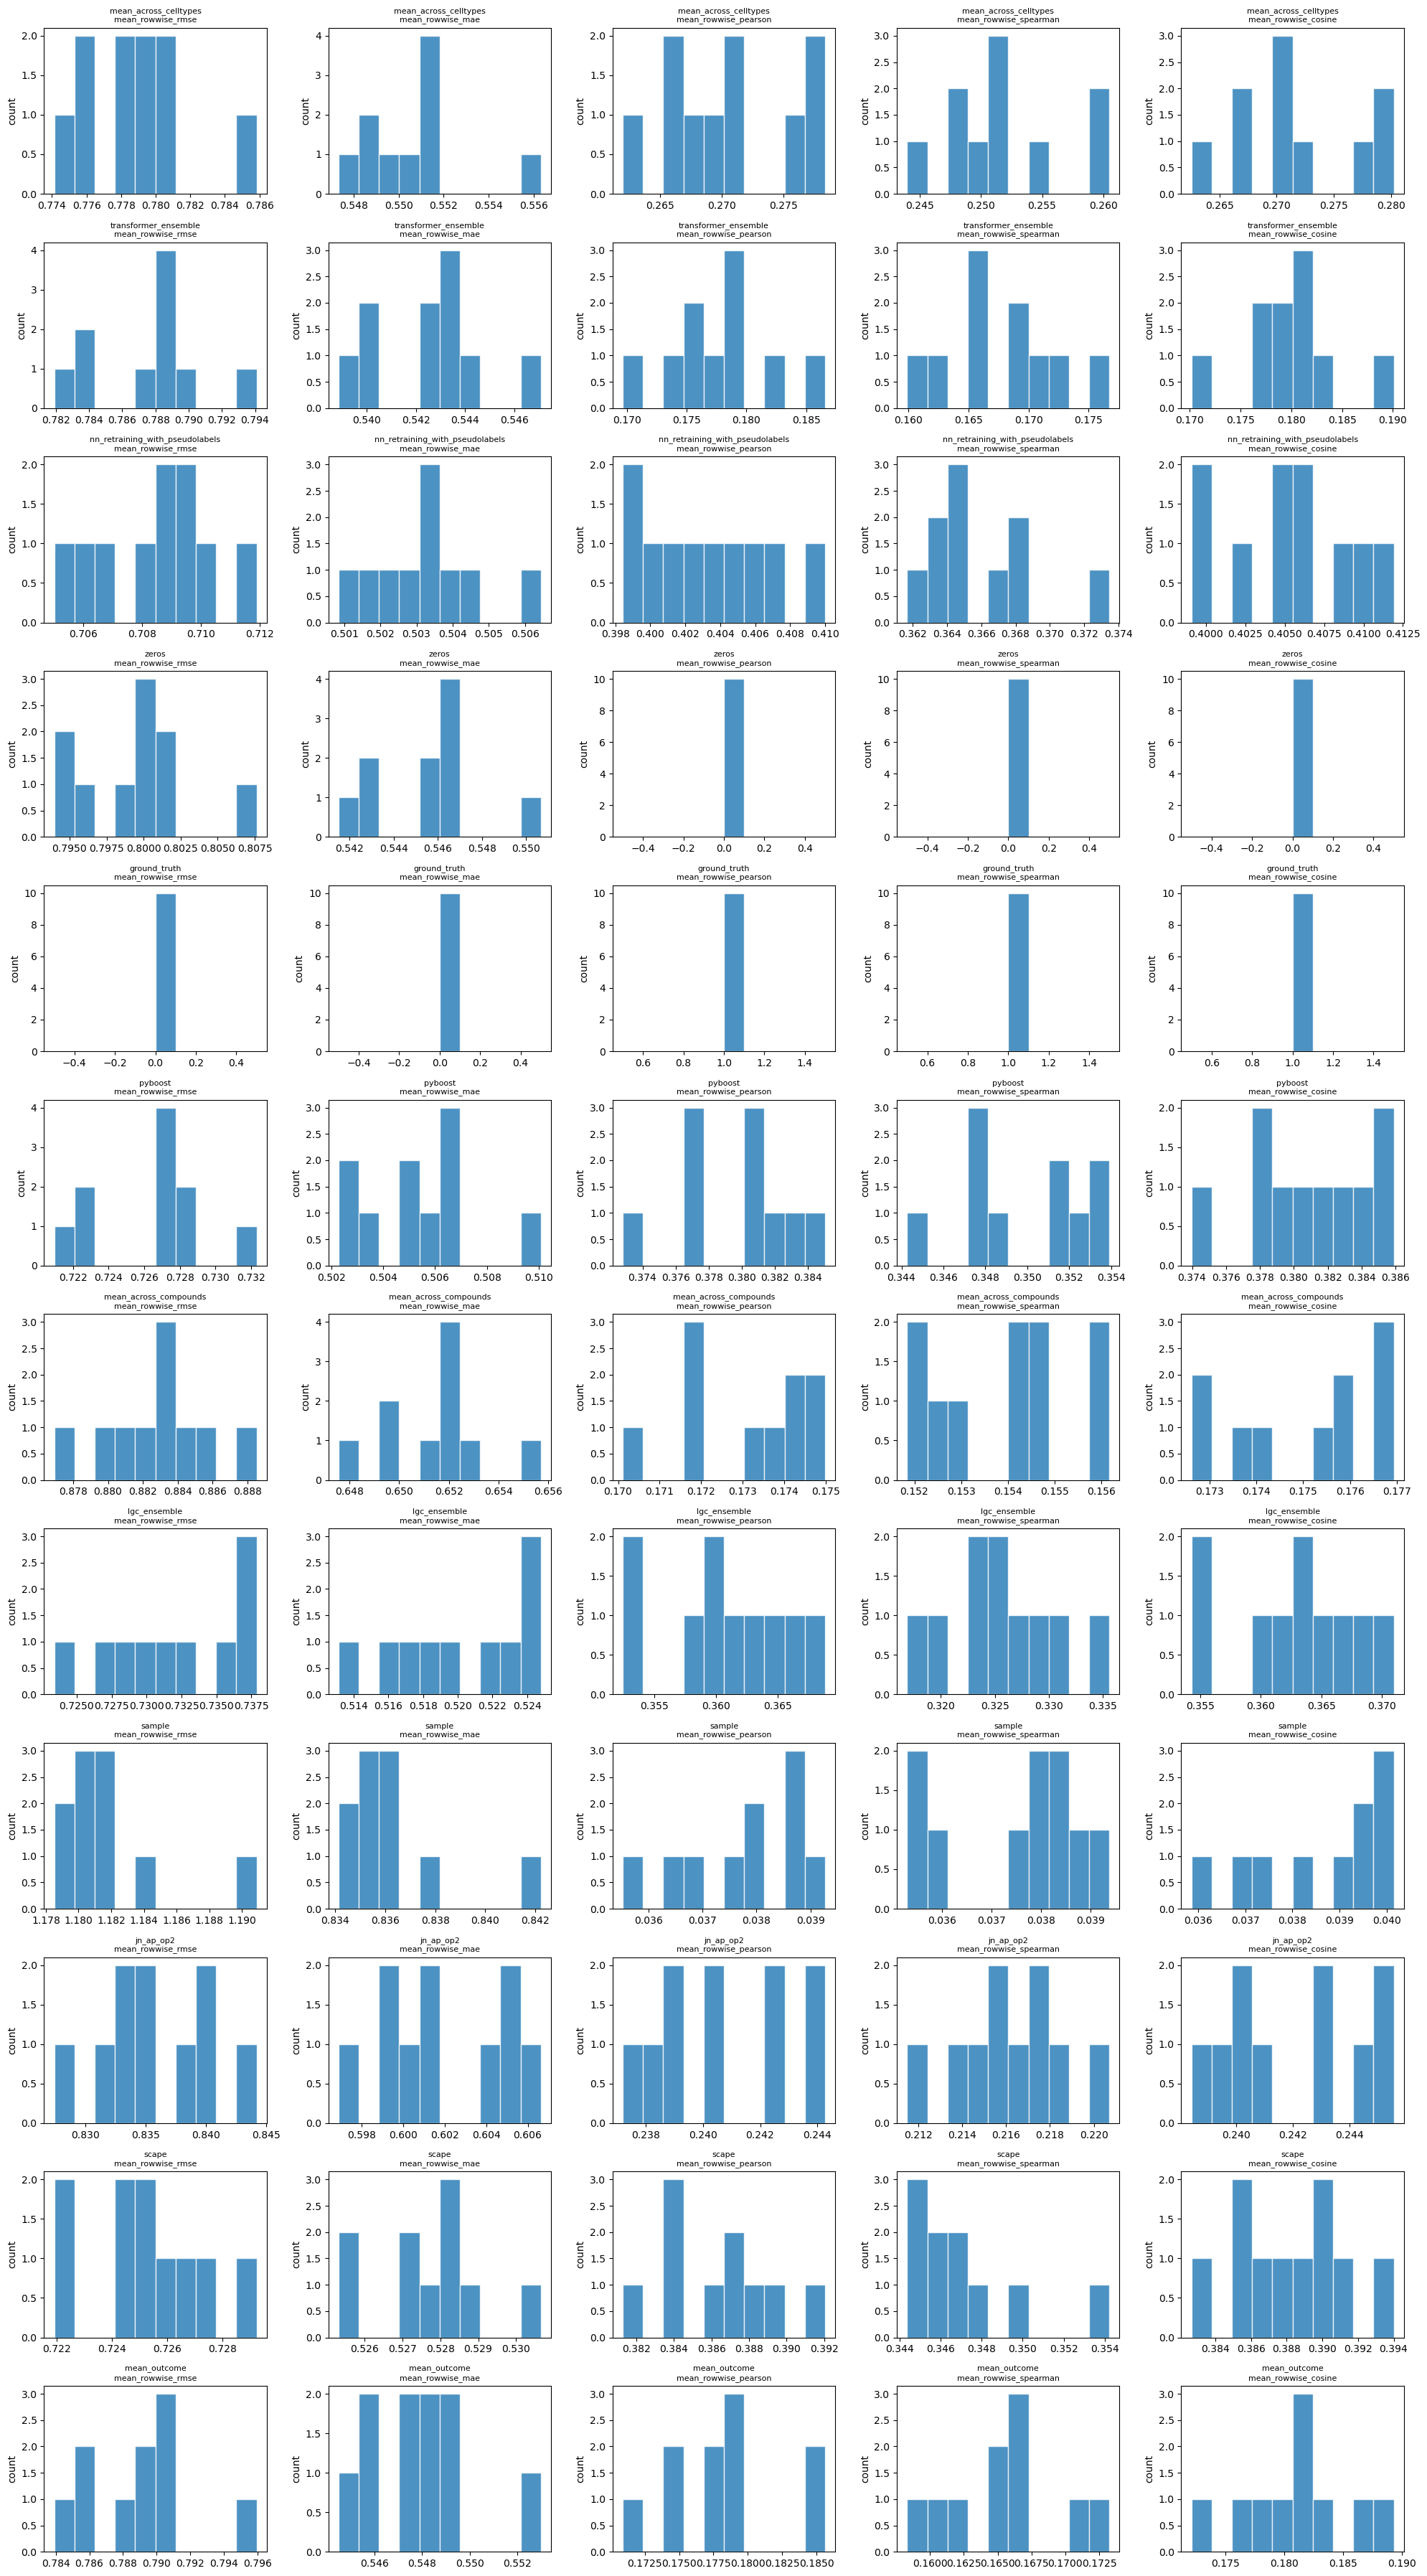

In [12]:
methods = df_long['method_id'].unique()
metrics = df_long['metric_id'].unique()
n_methods = len(methods)
n_metrics = len(metrics)

fig, axes = plt.subplots(n_methods, n_metrics, figsize=(4 * n_metrics, 3 * n_methods))
if n_methods == 1 and n_metrics == 1:
    axes = [[axes]]
elif n_methods == 1:
    axes = [axes]
elif n_metrics == 1:
    axes = [[a] for a in axes]

for i, method in enumerate(methods):
    for j, metric in enumerate(metrics):
        ax = axes[i][j]
        df_long_slice = df_long[(df_long['method_id'] == method) & (df_long['metric_id'] == metric)]
        ax.hist(df_long_slice['metric_value'], bins=min(30, max(10, len(df_long_slice) // 3)), edgecolor='white', alpha=0.8)
        ax.set_title(f'{method}\n{metric}', fontsize=8)
        ax.set_ylabel('count')
plt.tight_layout()
plt.show()

In [13]:
# Aggregate across bootstraps: mean, std, and percentiles [2.5, 97.5] per (method_type, method_id, metric_id)
df_bootstrap = (
    df_long.groupby(["method_type", "method_id", "metric_id"], as_index=False)["metric_value"]
    .agg([
        "mean",
        "std",
    ])
    .reset_index()
)

In [14]:
df = df_scores.merge(df_bootstrap.drop(columns=['index']), on=['method_id', 'metric_id'], how='left')

In [15]:
df['err_low'] = df['metric_value'] - df['std']
df['err_high'] = df['metric_value'] + df['std']

In [16]:
df

,dataset_id,method_id,metric_id,metric_value,method_type,mean,std,err_low,err_high
0,neurips-2023-data,mean_outcome,mean_rowwise_rmse,0.899233,control,0.789039,0.003476,0.895757,0.902709
1,neurips-2023-data,mean_outcome,mean_rowwise_mae,0.635633,control,0.547860,0.002350,0.633284,0.637983
2,neurips-2023-data,transformer_ensemble,mean_rowwise_pearson,0.221179,method,0.177964,0.004698,0.216481,0.225877
3,neurips-2023-data,transformer_ensemble,mean_rowwise_spearman,0.216377,method,0.167763,0.004901,0.211476,0.221278
4,neurips-2023-data,transformer_ensemble,mean_rowwise_cosine,0.226716,method,0.179962,0.005211,0.221505,0.231928
5,neurips-2023-data,mean_across_celltypes,mean_rowwise_pearson,0.297152,control,0.270310,0.005402,0.291750,0.302554
6,neurips-2023-data,mean_across_celltypes,mean_rowwise_spearman,0.280571,control,0.251809,0.005123,0.275447,0.285694
7,neurips-2023-data,mean_across_celltypes,mean_rowwise_cosine,0.301747,control,0.271643,0.005743,0.296005,0.307490
8,neurips-2023-data,ground_truth,mean_rowwise_pearson,1.000000,control,1.000000,0.000000,1.000000,1.000000
9,neurips-2023-data,ground_truth,mean_rowwise_spearman,1.000000,control,1.000000,0.000000,1.000000,1.000000


# Download results

In [17]:
def dict_to_pd(d):
    """Convert results dict to long format, then aggregate to same format as df_bootstrap."""
    rows = []
    for outer_key, inner in d.items():
        for metric_id, value in zip(inner["metric_ids"], inner["metric_values"]):
            rows.append({
                "dataset_id": inner["dataset_id"],
                "method_id": inner["method_id"],
                "metric_id": metric_id,
                "metric_value": value,
            })
    df_long = pd.DataFrame(rows)
    df_long["method_type"] = df_long["method_id"].map(
        lambda m: "control" if m in CONTROL_METHOD_IDS else "method"
    )
    
    return df_long

In [18]:
control_path = '../data/benchmark/results/metrics/control_methods/'
methods_path = '../data/benchmark/results/metrics/methods/'

In [19]:
file_name_err = 'mean_rowwise_error.h5ad'
file_name_corr = 'mean_rowwise_correlation.h5ad'

In [20]:
methods_err = {}
methods_corr = {}
for item in os.listdir(methods_path):
    err = ad.read_h5ad(f'{methods_path}{item}/{file_name_err}').uns
    corr = ad.read_h5ad(f'{methods_path}{item}/{file_name_corr}').uns
    methods_err[item] = err
    methods_corr[item] = corr

In [21]:
control_err = {}
control_corr = {}
for item in os.listdir(control_path):
    err = ad.read_h5ad(f'{control_path}{item}/{file_name_err}').uns
    corr = ad.read_h5ad(f'{control_path}{item}/{file_name_corr}').uns
    control_err[item] = err
    control_corr[item] = corr

In [22]:
df_res = pd.concat([dict_to_pd(methods_err), dict_to_pd(control_err), dict_to_pd(methods_corr), dict_to_pd(control_corr)]).reset_index(drop=True)

In [23]:
df_res = df_res.rename(columns={'dataset_id': 'dataset_id_replication',
                      'metric_value': 'metric_value_replication',
                      'method_type': 'method_type_replication',})

In [24]:
df = df.merge(df_res, on=['method_id', 'metric_id'], how='left')

In [25]:
df['in_interval'] = (df['metric_value_replication'] >= df['err_low']) & (df['metric_value_replication'] <= df['err_high'])

In [26]:
df[~df['in_interval']]

,dataset_id,method_id,metric_id,metric_value,method_type,mean,std,err_low,err_high,dataset_id_replication,metric_value_replication,method_type_replication,in_interval
8,neurips-2023-data,ground_truth,mean_rowwise_pearson,1.000000,control,1.000000,0.000000,1.000000,1.000000,neurips-2023-data,NaN,control,False
10,neurips-2023-data,ground_truth,mean_rowwise_cosine,1.000000,control,1.000000,0.000000,1.000000,1.000000,neurips-2023-data,NaN,control,False
52,neurips-2023-data,sample,mean_rowwise_pearson,0.052354,control,0.037742,0.001207,0.051147,0.053560,neurips-2023-data,0.050696,control,False
54,neurips-2023-data,sample,mean_rowwise_cosine,0.054682,control,0.038686,0.001436,0.053246,0.056118,neurips-2023-data,0.053091,control,False


In [27]:
df['method_metric'] = df['method_id'] + '_' + df['metric_id']

<BarContainer object of 60 artists>

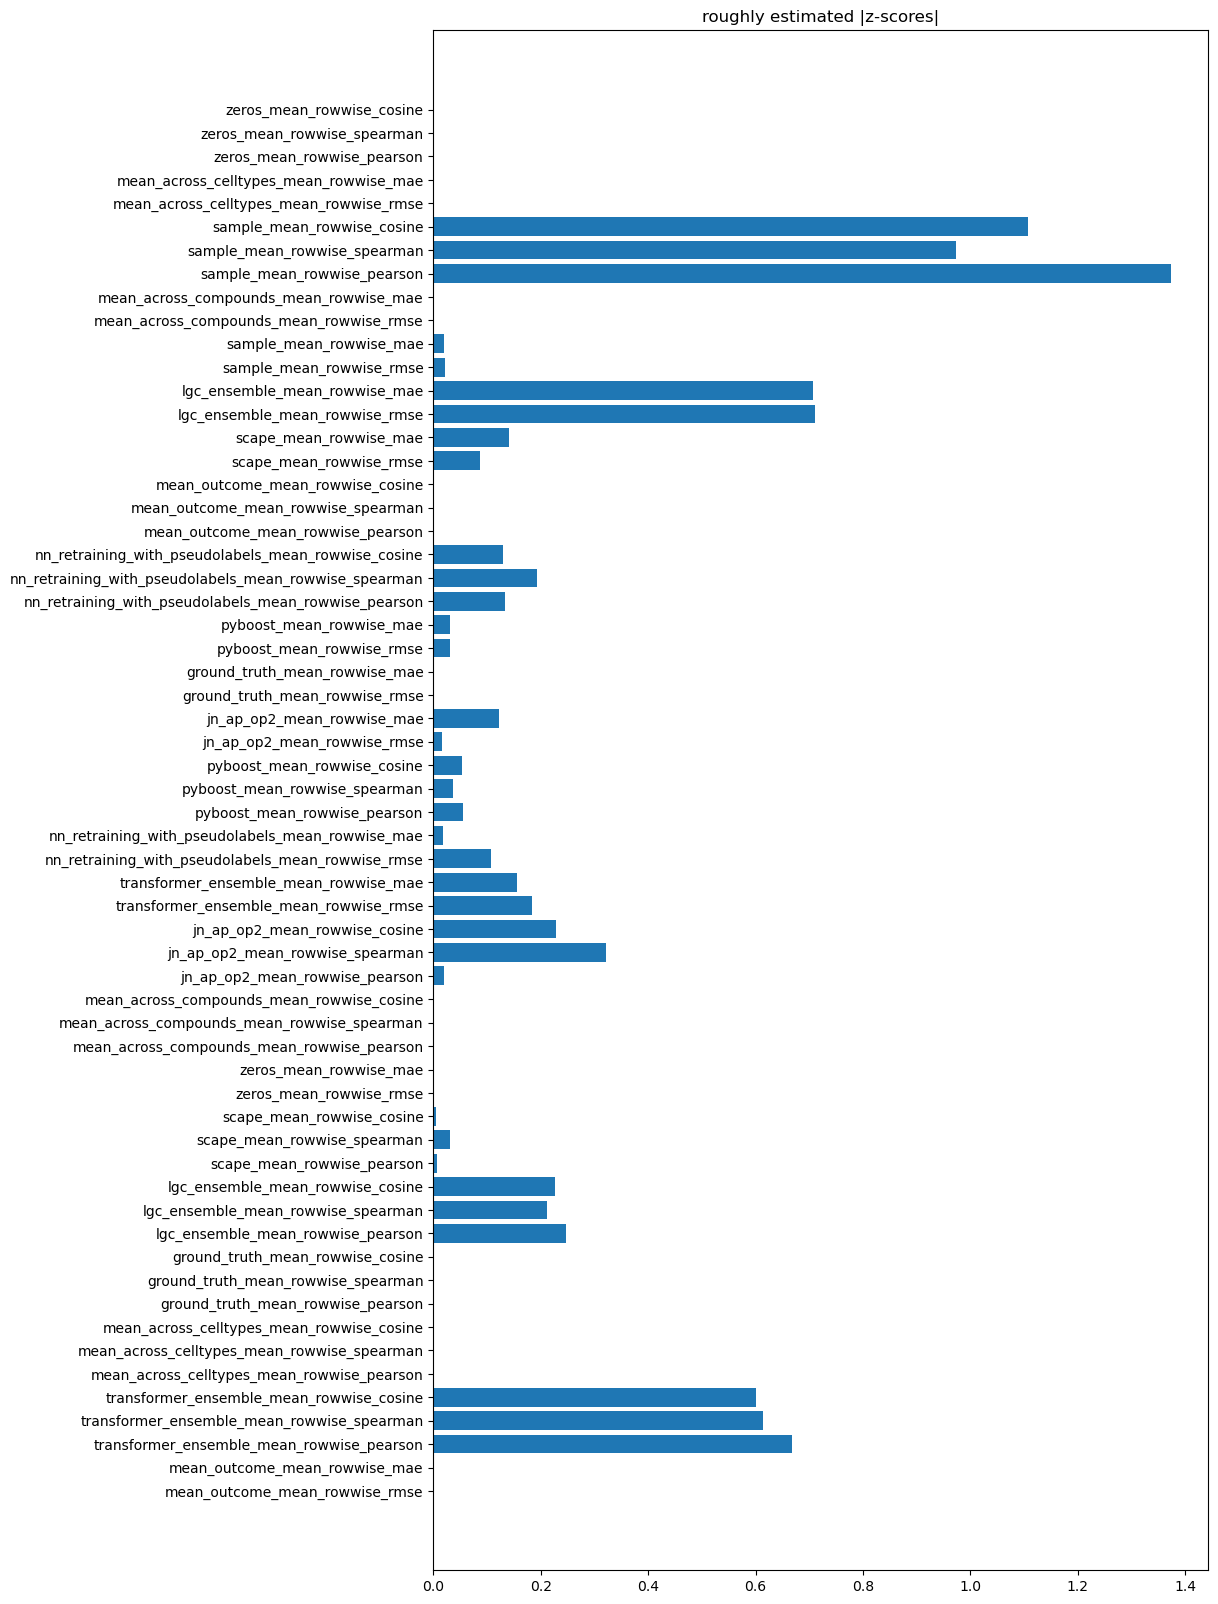

In [28]:
plt.figure(figsize=(10, 20))
plt.title('roughly estimated |z-scores|')
plt.barh(df['method_metric'], abs(df['metric_value_replication'] - df['metric_value'])/(df['std'] + 1e-15))